In [ ]:
# Core
import json
import numpy as np
import pandas as pd
import joblib
import random

# Visualization (unchanged)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# PyTorch (replaces TensorFlow/Keras)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna

In [2]:
# Device setup (PyTorch equivalent of TF GPU check)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)


Using device: cuda
GPU Name: NVIDIA GeForce GTX 1650
CUDA Version: 13.0


In [ ]:
scaler = joblib.load("../data/processed/X_scaler.pkl")
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")
X_trainVal = np.load("../data/processed/X_trainVal.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")
y_trainVal = np.load("../data/processed/y_trainVal.npy")
y_scaler = joblib.load("../data/processed/y_scaler.pkl")

with open("../data/processed/feature_names.json", "r") as f:
    feature_names = json.load(f)


In [7]:
class ParkinsonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [8]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [9]:

STUDY_NAME = "parkinsons_nn_optuna"
DB_PATH = "sqlite:///parkinsons_optuna.db"

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction="minimize",
    storage=DB_PATH,
    load_if_exists=True
)

print("Study loaded. Trials so far:", len(study.trials))


[I 2026-02-06 19:28:34,959] Using an existing study with name 'parkinsons_nn_optuna' instead of creating a new one.


Study loaded. Trials so far: 20


In [11]:
class ParkinsonNN(nn.Module):
    def __init__(self, trial, input_dim=18):
        super().__init__()

        # Hyperparameters to search
        l1 = trial.suggest_int("units_l1", 64, 256, step=64)
        l2 = trial.suggest_int("units_l2", 64, 128, step=32)
        l3 = trial.suggest_int("units_l3", 32, 64, step=16)
        l4 = trial.suggest_int("units_l4", 32, 64, step=16)

        dropout = trial.suggest_float("dropout", 0.0, 0.3)

        self.net = nn.Sequential(
            nn.Linear(input_dim, l1), nn.ReLU(),
            nn.Linear(l1, l2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(l2, l3), nn.ReLU(),
            nn.Linear(l3, l4), nn.ReLU(),
            nn.Linear(l4, 2)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def objective(trial):

    lr = trial.suggest_categorical("lr", [1e-3, 1e-2, 1e-1])
    weight_decay = trial.suggest_categorical("l2", [1e-4, 1e-3, 1e-2])
    batch_size = 32

    train_ds = ParkinsonDataset(X_train, y_train_scaled)
    val_ds   = ParkinsonDataset(X_val, y_val_scaled)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)

    model = ParkinsonNN(trial).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float("inf")
    patience = 20
    patience_ctr = 0
    # best_state = None

    for epoch in range(300):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item()

        val_loss /= len(val_loader)

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            # best_state = model.state_dict()
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    # trial.set_user_attr("best_state_dict", best_state)
    return best_val


In [ ]:
study.optimize(objective, n_trials=20)


In [12]:
print("Best trial:")
print(study.best_trial.params)


Best trial:
{'lr': 0.01, 'l2': 0.0001, 'units_l1': 64, 'units_l2': 64, 'units_l3': 64, 'units_l4': 32, 'dropout': 0.0003447602204319656}


In [13]:
best_params = study.best_trial.params
print(best_params)

# Save to disk (reproducibility!)
with open("../models/best_nn_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("Saved best_nn_params.json")


{'lr': 0.01, 'l2': 0.0001, 'units_l1': 64, 'units_l2': 64, 'units_l3': 64, 'units_l4': 32, 'dropout': 0.0003447602204319656}
Saved best_nn_params.json


In [14]:
# Load params (important for future reruns)
with open("../models/best_nn_params.json", "r") as f:
    params = json.load(f)

params


{'lr': 0.01,
 'l2': 0.0001,
 'units_l1': 64,
 'units_l2': 64,
 'units_l3': 64,
 'units_l4': 32,
 'dropout': 0.0003447602204319656}

In [15]:
class FinalParkinsonNN(nn.Module):
    def __init__(self, params, input_dim=18):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, params["units_l1"]), nn.ReLU(),
            nn.Linear(params["units_l1"], params["units_l2"]), nn.ReLU(),
            nn.Dropout(params["dropout"]),
            nn.Linear(params["units_l2"], params["units_l3"]), nn.ReLU(),
            nn.Linear(params["units_l3"], params["units_l4"]), nn.ReLU(),
            nn.Linear(params["units_l4"], 2)
        )

    def forward(self, x):
        return self.net(x)


In [17]:
BATCH_SIZE = 32
LR = params["lr"]
WEIGHT_DECAY = params["l2"]

train_ds = ParkinsonDataset(X_trainVal, y_trainVal)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

best_NN_model = FinalParkinsonNN(params).to(DEVICE)

optimizer = torch.optim.Adam(
    best_NN_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.MSELoss()


In [18]:
from tqdm import tqdm

best_loss = float("inf")

for epoch in range(500):
    best_NN_model.train()
    running_loss = 0.0

    loop = tqdm(train_loader, leave=False)
    for xb, yb in loop:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        outputs = best_NN_model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/500]")
        loop.set_postfix(batch_mse=loss.item())

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1:03d} | Train MSE: {epoch_loss:.6f}")

    # 🔥 Minimal safety
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(best_NN_model.state_dict(), "../models/best_nn_model.pt")
        print("  → Best model saved")

Epoch 001 | Train MSE: 0.738354
  → Best model saved


Epoch 002 | Train MSE: 0.519310
  → Best model saved


Epoch 003 | Train MSE: 0.430617
  → Best model saved


Epoch 004 | Train MSE: 0.385387
  → Best model saved


Epoch 005 | Train MSE: 0.368604
  → Best model saved


...

Epoch 496 | Train MSE: 0.096254


Epoch 497 | Train MSE: 0.100342


Epoch 498 | Train MSE: 0.111175


Epoch 499 | Train MSE: 0.121814


Epoch 500 | Train MSE: 0.115023


In [19]:
# best_NN_model.load_state_dict(torch.load("../models/best_nn_model.pt"))
best_NN_model.eval()


FinalParkinsonNN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.0003447602204319656, inplace=False)
    (5): Linear(in_features=64, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [20]:
# Convert test features to tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

# Run inference
with torch.no_grad():
    y_pred_scaled = best_NN_model(X_test_tensor).cpu().numpy()

# 🔴 IMPORTANT: inverse scaling (you scaled targets earlier)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Metrics (same as before)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Test MSE: 9.7498
R-squared Score: 0.8864


In [21]:
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


RMSE: 3.1225
MAE:  2.2576


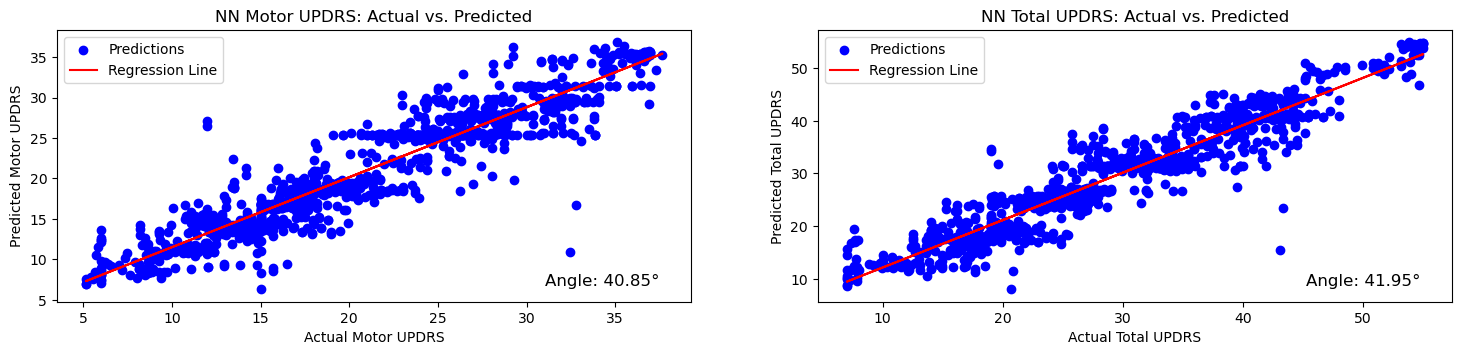

In [23]:
plt.figure(figsize=(18, 12))

def plot_with_angle(ax, actual, predicted, label, color, model_name):
    ax.scatter(actual, predicted, label='Predictions', color=color)

    slope, intercept = np.polyfit(actual, predicted, 1)
    regression_line = slope * actual + intercept
    ax.plot(actual, regression_line, color='red', label='Regression Line')

    angle = np.degrees(np.arctan(slope))
    ax.text(0.95, 0.05, f'Angle: {angle:.2f}°', transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{model_name} {label}: Actual vs. Predicted')
    ax.legend()

# NN plots
plt.subplot(3, 2, 1)
plot_with_angle(plt.gca(), y_test[:, 0], y_pred[:, 0], 'Motor UPDRS', 'blue', 'NN')

plt.subplot(3, 2, 2)
plot_with_angle(plt.gca(), y_test[:, 1], y_pred[:, 1], 'Total UPDRS', 'blue', 'NN')